In [1]:
!apt-get install openjdk-11-jdk-headless -qq > /dev/null
!wget https://archive.apache.org/dist/spark/spark-3.5.1/spark-3.5.1-bin-hadoop3.tgz
!tar xf spark-3.5.1-bin-hadoop3.tgz

!pip install -q findspark
!ls -l /content/spark-3.5.1-bin-hadoop3/
!ls -l /content/spark-3.5.1-bin-hadoop3/python/
!ls -l /content/spark-3.5.1-bin-hadoop3/python/lib/
import os
import findspark

os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.5.1-bin-hadoop3"

findspark.init()
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("MES_Energy_Analysis") \
    .getOrCreate()


--2026-07-14 14:13:30--  https://archive.apache.org/dist/spark/spark-3.5.1/spark-3.5.1-bin-hadoop3.tgz
Resolving archive.apache.org (archive.apache.org)... 65.108.204.189, 2a01:4f9:1a:a084::2
Connecting to archive.apache.org (archive.apache.org)|65.108.204.189|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 400446614 (382M) [application/x-gzip]
Saving to: ‘spark-3.5.1-bin-hadoop3.tgz’

spark-3.5.1-bin-had 100%[===================>] 381.90M   740KB/s    in 12m 42s 

2026-07-14 14:26:12 (513 KB/s) - ‘spark-3.5.1-bin-hadoop3.tgz’ saved [400446614/400446614]

total 156
drwxr-xr-x 2 1000 1000  4096 Feb 15  2024 bin
drwxr-xr-x 2 1000 1000  4096 Feb 15  2024 conf
drwxr-xr-x 6 1000 1000  4096 Feb 15  2024 data
drwxr-xr-x 4 1000 1000  4096 Feb 15  2024 examples
drwxr-xr-x 2 1000 1000 20480 Feb 15  2024 jars
drwxr-xr-x 4 1000 1000  4096 Feb 15  2024 kubernetes
-rw-r--r-- 1 1000 1000 22916 Feb 15  2024 LICENSE
drwxr-xr-x 2 1000 1000  4096 Feb 15  2024 licenses
-rw-r--r--

In [2]:
df = spark.read.csv(
    "/content/Energy_consumption_dataset.csv",
    header=True,
    inferSchema=True
)

df.show(5)

+-----+----+---------+-------+------------------+------------------+------------------+---------+---------+-------------+------------------+-----------------+
|Month|Hour|DayOfWeek|Holiday|       Temperature|          Humidity|     SquareFootage|Occupancy|HVACUsage|LightingUsage|   RenewableEnergy|EnergyConsumption|
+-----+----+---------+-------+------------------+------------------+------------------+---------+---------+-------------+------------------+-----------------+
|    1|   0| Saturday|     No|  25.1394334377269| 43.43158120480281|1565.6939992511177|        5|       On|          Off| 2.774698791658742|75.36437339539214|
|    1|   1| Saturday|     No|27.731650520792968|54.225918580233085| 1411.064918331917|        1|       On|           On|21.831384152500608|83.40185495035139|
|    1|   2| Saturday|     No|28.704276857248125|58.907657743033184|  1755.71500922237|        2|      Off|          Off|  6.76467168191291|78.27088774061066|
|    1|   3| Saturday|     No|20.0804694852981

In [3]:
df.describe().show()


+-------+------------------+------------------+---------+-------+------------------+-----------------+------------------+------------------+---------+-------------+------------------+-----------------+
|summary|             Month|              Hour|DayOfWeek|Holiday|       Temperature|         Humidity|     SquareFootage|         Occupancy|HVACUsage|LightingUsage|   RenewableEnergy|EnergyConsumption|
+-------+------------------+------------------+---------+-------+------------------+-----------------+------------------+------------------+---------+-------------+------------------+-----------------+
|  count|              5000|              5000|     5000|   5000|              5000|             5000|              5000|              5000|     5000|         5000|              5000|             5000|
|   mean|            6.2512|            11.556|     NULL|   NULL|24.946822966670933|45.47814600927515|1507.4032013901863|             4.576|     NULL|         NULL|15.201194654945683|76.794918

In [4]:
hourly_usage = df.groupBy("Hour") \
                 .avg("EnergyConsumption") \
                 .orderBy("Hour")

hourly_usage.show()

+----+----------------------+
|Hour|avg(EnergyConsumption)|
+----+----------------------+
|   0|     77.38751518193027|
|   1|     78.32910415822136|
|   2|     77.25513444890738|
|   3|     76.78766403303403|
|   4|     77.45020125833112|
|   5|     75.45625471064582|
|   6|     76.14893511094466|
|   7|     76.96501801980742|
|   8|     76.55360281075558|
|   9|     76.19785465514711|
|  10|     77.40060300235127|
|  11|     76.98362294020954|
|  12|     76.24302985413811|
|  13|      76.4573970050361|
|  14|     76.80809763590983|
|  15|     77.19279538337227|
|  16|     76.73044980768098|
|  17|     77.46326517110226|
|  18|      75.9765107459384|
|  19|     76.74909294038247|
+----+----------------------+
only showing top 20 rows



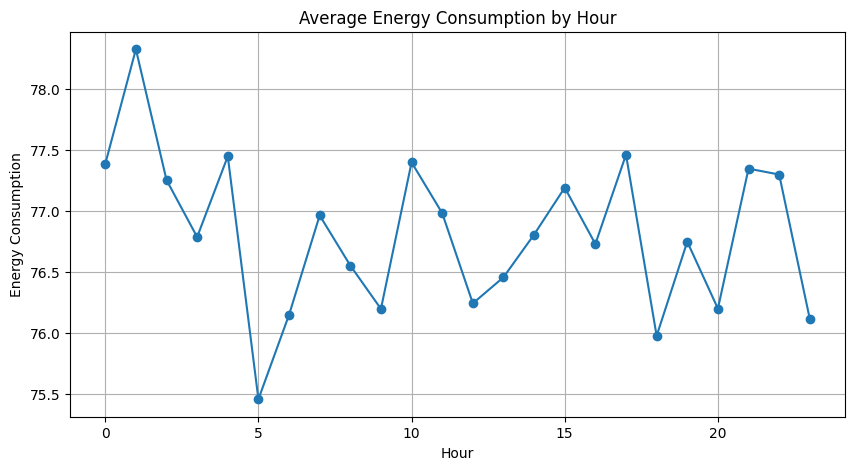

In [5]:
hourly_pd = hourly_usage.toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(hourly_pd["Hour"],
         hourly_pd["avg(EnergyConsumption)"],
         marker='o')

plt.title("Average Energy Consumption by Hour")
plt.xlabel("Hour")
plt.ylabel("Energy Consumption")
plt.grid(True)
plt.show()

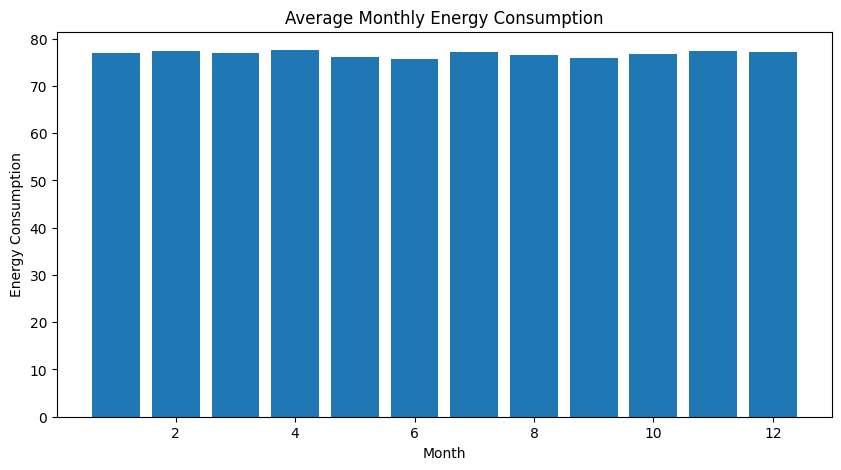

In [6]:
monthly_usage = df.groupBy("Month") \
                  .avg("EnergyConsumption") \
                  .orderBy("Month")

monthly_pd = monthly_usage.toPandas()

plt.figure(figsize=(10,5))
plt.bar(monthly_pd["Month"],
        monthly_pd["avg(EnergyConsumption)"])

plt.title("Average Monthly Energy Consumption")
plt.xlabel("Month")
plt.ylabel("Energy Consumption")
plt.show()

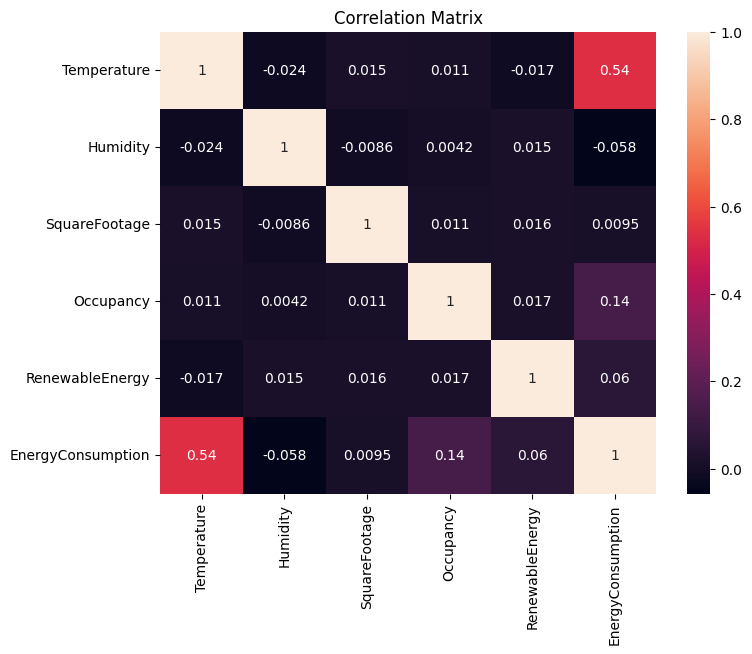

In [7]:
numeric_cols = [
    "Temperature",
    "Humidity",
    "SquareFootage",
    "Occupancy",
    "RenewableEnergy",
    "EnergyConsumption"
]

pandas_df = df.select(numeric_cols).toPandas()

import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(pandas_df.corr(),
            annot=True)

plt.title("Correlation Matrix")
plt.show()

In [8]:
from pyspark.ml.feature import StringIndexer

day_indexer = StringIndexer(
    inputCol="DayOfWeek",
    outputCol="DayOfWeekIndex"
)

holiday_indexer = StringIndexer(
    inputCol="Holiday",
    outputCol="HolidayIndex"
)

hvac_indexer = StringIndexer(
    inputCol="HVACUsage",
    outputCol="HVACIndex"
)

light_indexer = StringIndexer(
    inputCol="LightingUsage",
    outputCol="LightingIndex"
)

In [9]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=[
        "Month",
        "Hour",
        "Temperature",
        "Humidity",
        "SquareFootage",
        "Occupancy",
        "RenewableEnergy",
        "DayOfWeekIndex",
        "HolidayIndex",
        "HVACIndex",
        "LightingIndex"
    ],
    outputCol="features"
)

In [10]:
from pyspark.ml.regression import LinearRegression
from pyspark.ml import Pipeline

pipeline = Pipeline(stages=[
    day_indexer,
    holiday_indexer,
    hvac_indexer,
    light_indexer,
    assembler
])

prepared_data = pipeline.fit(df).transform(df)

In [11]:
train_data, test_data = prepared_data.randomSplit(
    [0.8, 0.2],
    seed=42
)

In [12]:
lr = LinearRegression(
    featuresCol="features",
    labelCol="EnergyConsumption"
)

model = lr.fit(train_data)

In [13]:
predictions = model.transform(test_data)

predictions.select(
    "EnergyConsumption",
    "prediction"
).show(10)

+-----------------+-----------------+
|EnergyConsumption|       prediction|
+-----------------+-----------------+
|69.61597783748148|71.14623107638567|
|82.49632388751793|77.99138874886246|
| 79.2849224435124|81.96585726608353|
|92.94947424303056|87.32758816427621|
|76.93645309620132|70.41804190155536|
|75.91390632236421|76.65872679427846|
|75.98238074965289|79.08078603876629|
|69.30518444855907|70.87027287012461|
|64.29007163380574|67.25748979322711|
|77.39615132557863|74.25558908627018|
+-----------------+-----------------+
only showing top 10 rows



In [14]:
from pyspark.ml.evaluation import RegressionEvaluator

evaluator = RegressionEvaluator(
    labelCol="EnergyConsumption",
    predictionCol="prediction",
    metricName="r2"
)

r2 = evaluator.evaluate(predictions)

print("R2 Score:", r2)

R2 Score: 0.30756235747478655


In [15]:
from pyspark.ml.regression import RandomForestRegressor

rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="EnergyConsumption",
    numTrees=100,
    maxDepth=10,
    seed=42
)

rf_model = rf.fit(train_data)

In [16]:
rf_predictions = rf_model.transform(test_data)

rf_predictions.select(
    "EnergyConsumption",
    "prediction"
).show(10)

+-----------------+-----------------+
|EnergyConsumption|       prediction|
+-----------------+-----------------+
|69.61597783748148|73.90891898801891|
|82.49632388751793|78.34013715373398|
| 79.2849224435124|80.58246977968696|
|92.94947424303056|84.79371545919341|
|76.93645309620132|71.37016405032767|
|75.91390632236421|77.43532826416896|
|75.98238074965289|80.57348874014521|
|69.30518444855907|71.42567156469187|
|64.29007163380574|67.86458005604423|
|77.39615132557863|76.75660527936564|
+-----------------+-----------------+
only showing top 10 rows



In [17]:
from pyspark.ml.evaluation import RegressionEvaluator

r2_evaluator = RegressionEvaluator(
    labelCol="EnergyConsumption",
    predictionCol="prediction",
    metricName="r2"
)

r2 = r2_evaluator.evaluate(rf_predictions)

print("Random Forest R² Score:", r2)

Random Forest R² Score: 0.28985880431433897


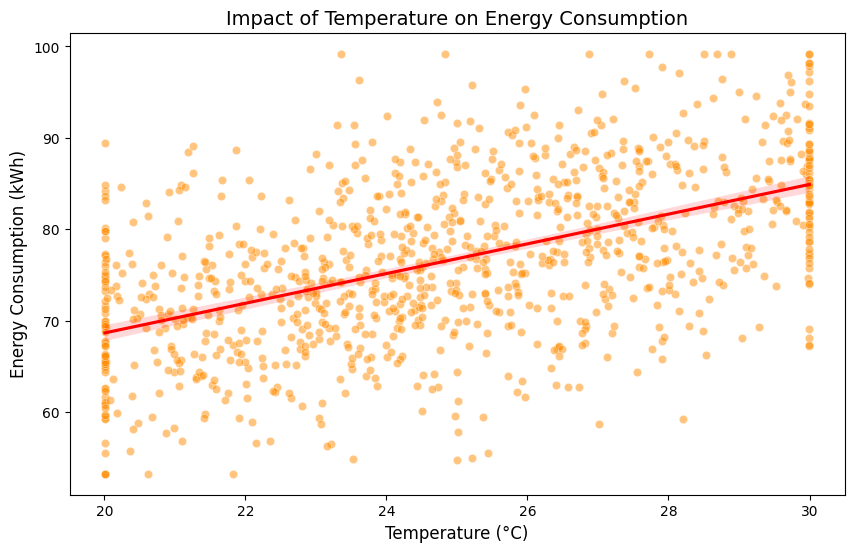

In [18]:
# Since it's a scatter plot, we sample the data if it's too large, or plot directly if it fits in memory
# Converting a sample to Pandas for visualization safety
scatter_df = df.select("Temperature", "EnergyConsumption").sample(withReplacement=False, fraction=0.2, seed=42).toPandas()

# Plotting
plt.figure(figsize=(10, 6))
sns.scatterplot(data=scatter_df, x="Temperature", y="EnergyConsumption", alpha=0.5, color="darkorange")
sns.regplot(data=scatter_df, x="Temperature", y="EnergyConsumption", scatter=False, color="red") # Trendline
plt.title("Impact of Temperature on Energy Consumption", fontsize=14)
plt.xlabel("Temperature (°C)", fontsize=12)
plt.ylabel("Energy Consumption (kWh)", fontsize=12)
plt.show()

In [19]:
from pyspark.ml.evaluation import RegressionEvaluator

rmse_evaluator = RegressionEvaluator(
    labelCol="EnergyConsumption",
    predictionCol="prediction",
    metricName="rmse"
)

lr_rmse = rmse_evaluator.evaluate(predictions)
rf_rmse = rmse_evaluator.evaluate(rf_predictions)

print("Linear Regression RMSE:", lr_rmse)
print("Random Forest RMSE:", rf_rmse)

Linear Regression RMSE: 7.841785835917423
Random Forest RMSE: 7.941398623278522


In [20]:
from pyspark.sql.functions import mean, lit
mean_val = train_data.select(mean("EnergyConsumption")).first()[0]
baseline_predictions = test_data.withColumn("prediction", lit(mean_val))
baseline_rmse = rmse_evaluator.evaluate(baseline_predictions)
print("Baseline (mean) RMSE:", baseline_rmse)

Baseline (mean) RMSE: 9.431512040823465


In [21]:
importances = list(zip(assembler.getInputCols(), rf_model.featureImportances.toArray()))
for feature, score in sorted(importances, key=lambda x: -x[1]):
    print(feature, round(score, 4))

Temperature 0.4503
RenewableEnergy 0.0809
SquareFootage 0.0803
DayOfWeekIndex 0.0778
Humidity 0.0747
Hour 0.0693
Occupancy 0.0667
Month 0.0574
HVACIndex 0.0146
HolidayIndex 0.0145
LightingIndex 0.0135


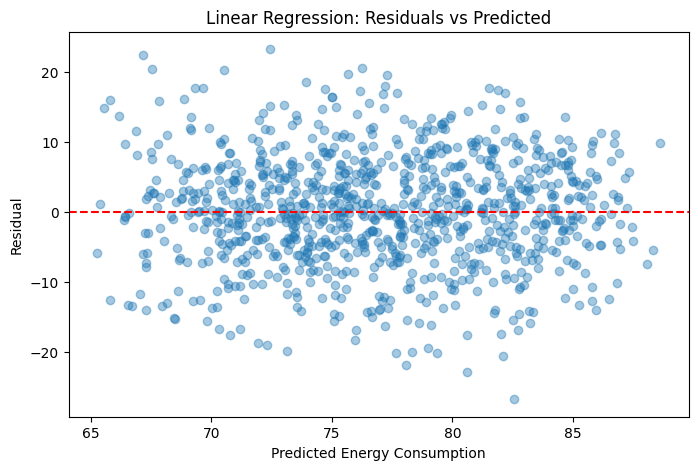

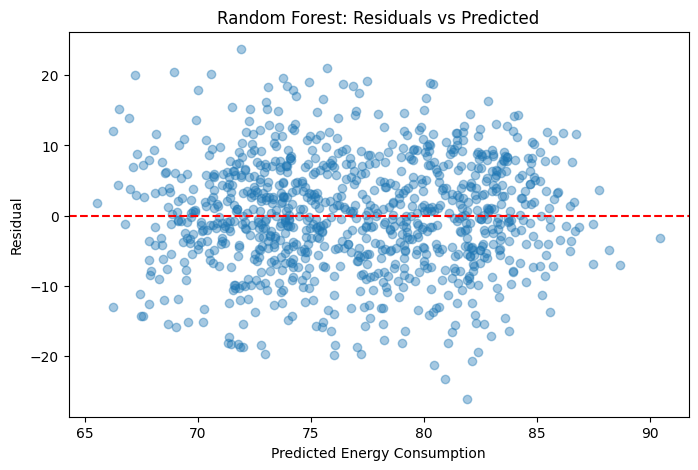

In [22]:

import matplotlib.pyplot as plt

# Convert predictions to pandas for plotting
lr_results = predictions.select("EnergyConsumption", "prediction").toPandas()
lr_results["residual"] = lr_results["EnergyConsumption"] - lr_results["prediction"]

rf_results = rf_predictions.select("EnergyConsumption", "prediction").toPandas()
rf_results["residual"] = rf_results["EnergyConsumption"] - rf_results["prediction"]

# Residuals vs Predicted (LR)
plt.figure(figsize=(8,5))
plt.scatter(lr_results["prediction"], lr_results["residual"], alpha=0.4)
plt.axhline(0, color="red", linestyle="--")
plt.title("Linear Regression: Residuals vs Predicted")
plt.xlabel("Predicted Energy Consumption")
plt.ylabel("Residual")
plt.show()

# Residuals vs Predicted (RF)
plt.figure(figsize=(8,5))
plt.scatter(rf_results["prediction"], rf_results["residual"], alpha=0.4)
plt.axhline(0, color="red", linestyle="--")
plt.title("Random Forest: Residuals vs Predicted")
plt.xlabel("Predicted Energy Consumption")
plt.ylabel("Residual")
plt.show()

In [23]:
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.regression import RandomForestRegressor

rf = RandomForestRegressor(labelCol="EnergyConsumption", featuresCol="features")

paramGrid = (ParamGridBuilder()
             .addGrid(rf.numTrees, [20, 50, 100])
             .addGrid(rf.maxDepth, [5, 10, 15])
             .build())

cv = CrossValidator(estimator=rf,
                     estimatorParamMaps=paramGrid,
                     evaluator=rmse_evaluator,
                     numFolds=5)

cv_model = cv.fit(train_data)
best_rf = cv_model.bestModel

print("Best numTrees:", best_rf.getNumTrees)
print("Best maxDepth:", best_rf.getOrDefault("maxDepth"))

tuned_predictions = best_rf.transform(test_data)
tuned_rmse = rmse_evaluator.evaluate(tuned_predictions)
print("Tuned RF RMSE:", tuned_rmse)

Best numTrees: 100
Best maxDepth: 10
Tuned RF RMSE: 7.93753371868132


In [24]:
importances = list(zip(assembler.getInputCols(), rf_model.featureImportances.toArray()))
for feature, score in sorted(importances, key=lambda x: -x[1]):
    print(feature, round(score, 4))

Temperature 0.4503
RenewableEnergy 0.0809
SquareFootage 0.0803
DayOfWeekIndex 0.0778
Humidity 0.0747
Hour 0.0693
Occupancy 0.0667
Month 0.0574
HVACIndex 0.0146
HolidayIndex 0.0145
LightingIndex 0.0135
